# MWE: sparse images with gradient CLEAN, starlet L1 and log-sum penalties

Maximum entropy and the other smoothness penalties prefer images whose flux is spread out. Some scenes are not like that: a few compact knots, perhaps with one extended feature, next to a bright star. This notebook reconstructs such a scene with the sparse tools of `virgil.imaging` (see `design/sparse_imaging.md`):
- **`clean`**, gradient CLEAN. It adds point components one at a time where they lower χ² most, using the gradient of the likelihood, so it works for DISCO and closure phases, not only for calibrated visibilities;
- **`StarletL1`**, an L1 norm of the image's wavelet (starlet) coefficients, which prefers images made of few compact structures at any scale;
- **`LogSum`**, a smooth surrogate for the number of bright pixels (SQUEEZE's L0).

An L1 norm of the pixels themselves would do nothing: an `Image`'s pixels are positive and sum to one, so their L1 norm is always one.

The data are simulated JWST AMI DISCOs of a star with three compact knots and one extended blob, 3.5% of the flux in all.

In [1]:
import sys
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro.distributions as dist

from virgil.coverage import ami_grid_record
from virgil.imaging import (
    LogSum,
    MaxEntropy,
    StarletL1,
    beam,
    clean,
    convolve_beam,
    field_of_view,
    image_priors,
    l_curve,
)
from virgil.likelihood import whitened_residuals
from virgil.models import Image, PointSource, System, circular_support
from virgil.oidata import OIData
from virgil.plotting import plot_model
from virgil.scenes import gaussian_blob

template = OIData(ami_grid_record(wavelength_m=4.8e-6, rotation_deg=-6.9))
scale = 20.0
npix = round(field_of_view(template, largest_mas=1250.0) / scale)
fov = npix * scale
features = [  # (dra, ddec, sigma, flux): three knots and a blob
    (-200.0, 140.0, 10.0, 0.010),
    (180.0, 80.0, 10.0, 0.006),
    (60.0, -220.0, 10.0, 0.007),
    (-120.0, -140.0, 60.0, 0.012),
]
truth_image = sum(
    f * gaussian_blob(npix, scale, s, dra=x, ddec=y) for x, y, s, f in features
)
flux = float(truth_image.sum())
truth = System(
    star=PointSource(),
    env=Image.from_brightness(truth_image, scale, flux=flux),
)
data = template.with_model(truth, key=jax.random.PRNGKey(0))
resolution = beam(data)
chi2_truth = jnp.mean(whitened_residuals(truth, data) ** 2)
print(
    f"{data.n_independent} data; {npix}² pixels of {scale:.0f} mas; beam "
    f"{resolution.major_mas:.0f} × {resolution.minor_mas:.0f} mas; "
    f"the truth has χ²/N = {chi2_truth:.3f}"
)

588 data; 62² pixels of 20 mas; beam 154 × 131 mas; the truth has χ²/N = 1.012


## Gradient CLEAN

`clean` starts from the star alone (`base=PointSource()`). Each iteration computes the gradient of χ² with respect to the flux of a point at every pixel, picks the pixel where a Gauss–Newton step would lower χ² most, and adds a tenth (the loop gain) of that step. It stops when χ² per point reaches one. For data linear in the image this is exactly Högbom's CLEAN. A hole of half a beam under the star keeps CLEAN from trading the star's flux against pixels right next to it.

The components are point-like by construction, so the extended blob becomes a cluster of them. The restored image, the components convolved with the beam, shows what the data resolve.

stopped (target) after 58 iterations at χ²/N = 0.971; 21 components with flux 0.0346 (truth 0.0350)


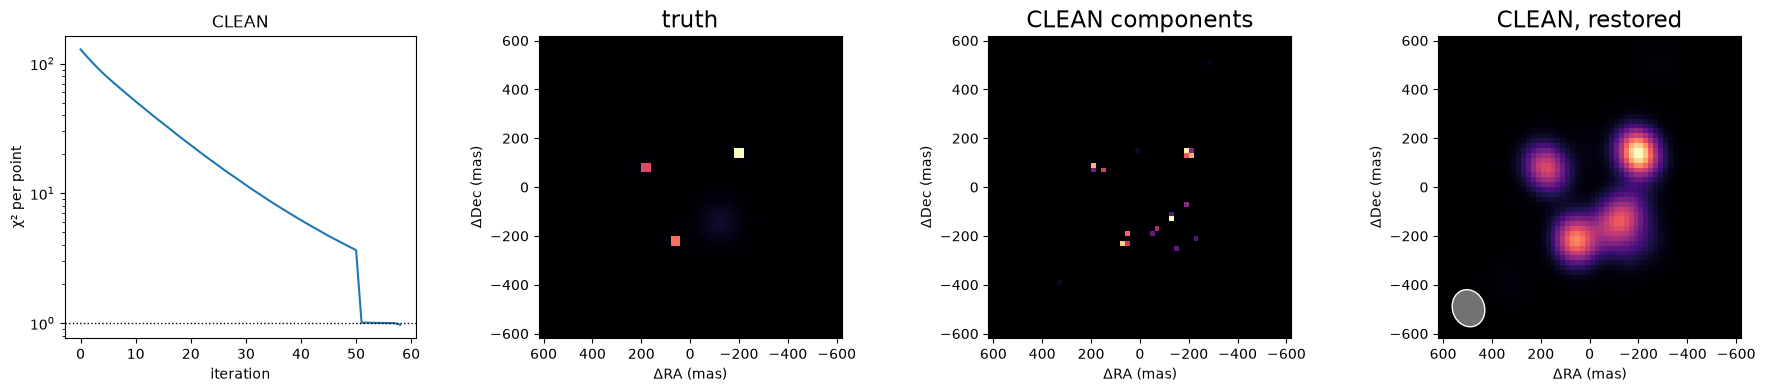

In [2]:
support = circular_support(
    npix, scale, radius_mas=fov / 2, inner_radius_mas=0.5 * resolution.minor_mas
)
result = clean(
    data, npix, scale, base=PointSource(), support=support, max_iterations=3000
)
print(
    f"stopped ({result.stop}) after {len(result.chi2_red) - 1} iterations at "
    f"χ²/N = {result.chi2_red[-1]:.3f}; {int((result.components > 0).sum())} "
    f"components with flux {float(result.components.sum()):.4f} "
    f"(truth {flux:.4f})"
)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].semilogy(result.chi2_red)
axes[0].axhline(1.0, color="k", ls=":", lw=1)
axes[0].set(xlabel="iteration", ylabel="χ² per point", title="CLEAN")
plot_model(truth.env, fov, npix, ax=axes[1], title="truth")
plot_model(result.model.clean, fov, npix, ax=axes[2], title="CLEAN components")
plot_model(
    result.model.clean, fov, npix, ax=axes[3], title="CLEAN, restored",
    beam=resolution, convolve=True,
)
plt.tight_layout()
plt.show()

## Regularised fits, started from CLEAN

The restored CLEAN image makes a good starting image for regularised maximum likelihood. Each regulariser's weight is swept and chosen by the discrepancy principle: the strongest weight whose fit reaches χ² per point of one. Maximum entropy is included for comparison. All three are swept with `l_curve`, from strong to weak. MEM and `StarletL1` start each fit from the previous one. `LogSum` is not convex, and must not be swept that way: a strong weight switches most pixels off, and they cannot recover in the weaker fits that follow. So it is swept with `warm_start=False`, and every fit starts from the CLEAN image.

In [3]:
start = System(
    star=PointSource(),
    env=Image.from_brightness(
        jnp.maximum(convolve_beam(result.components, scale, resolution), 0.0),
        scale,
        floor=1e-3,
        support=support,
        flux=float(result.components.sum()),
    ),
)
priors = image_priors(start) | {"env.flux": dist.LogUniform(1e-3, 2.0)}
settings = {
    "MEM": (MaxEntropy(1.0, path="env"), jnp.logspace(-1, 4, 11), True),
    "StarletL1": (StarletL1(1.0, path="env"), jnp.logspace(-2, 4, 13), True),
    # LogSum switches pixels off, so each weight starts from the CLEAN image.
    "LogSum": (LogSum(1.0, path="env"), jnp.logspace(-4, 0, 9), False),
}
sweeps = {
    name: l_curve(
        start, priors, data, regulariser, weights, warm_start=warm,
        max_steps=50_000,
    )
    for name, (regulariser, weights, warm) in settings.items()
}
fits = {name: (c.weights, c.results) for name, c in sweeps.items()}


def discrepancy(weights, results):
    # The strongest weight whose fit has χ²/N at most one, else the best fit.
    for w, r in zip(weights, results):
        if r.info["chi2_red"] <= 1.0:
            return float(w), r
    k = min(range(len(results)), key=lambda i: results[i].info["chi2_red"])
    return float(weights[k]), results[k]


chosen = {}
for name, (weights, results) in fits.items():
    w, r = chosen[name] = discrepancy(weights, results)
    print(
        f"{name}: w = {w:.3g}, χ²/N = {r.info['chi2_red']:.3f}, flux "
        f"{float(r.model.env.flux):.4f}; all converged: "
        f"{all(f.info['converged'] for f in results)}"
    )

/var/tmp/jobfs/virgil/src/virgil/imaging.py:1904: RuntimeWarning: fit(method='lbfgs') did not converge in 50000 steps, the step limit; raise max_steps.
  result = fit(


MEM: w = 31.6, χ²/N = 0.934, flux 0.0358; all converged: False
StarletL1: w = 100, χ²/N = 0.968, flux 0.0358; all converged: False
LogSum: w = 0.00316, χ²/N = 0.979, flux 0.0346; all converged: True


## Comparison

The top row shows each image at its native resolution, the bottom row convolved with the beam. NCC is the normalised cross-correlation with the truth (1 is perfect), at native resolution and after convolving both with the beam. "Top 2%" is the fraction of the image's flux in its brightest 2% of pixels, a measure of how compact it is.

truth      NCC 1.00 native, 1.00 convolved; top 2% 0.87
CLEAN      NCC 0.66 native, 1.00 convolved; top 2% 1.00
MEM        NCC 0.94 native, 1.00 convolved; top 2% 0.80
StarletL1  NCC 0.83 native, 1.00 convolved; top 2% 0.78
LogSum     NCC 0.70 native, 1.00 convolved; top 2% 1.00


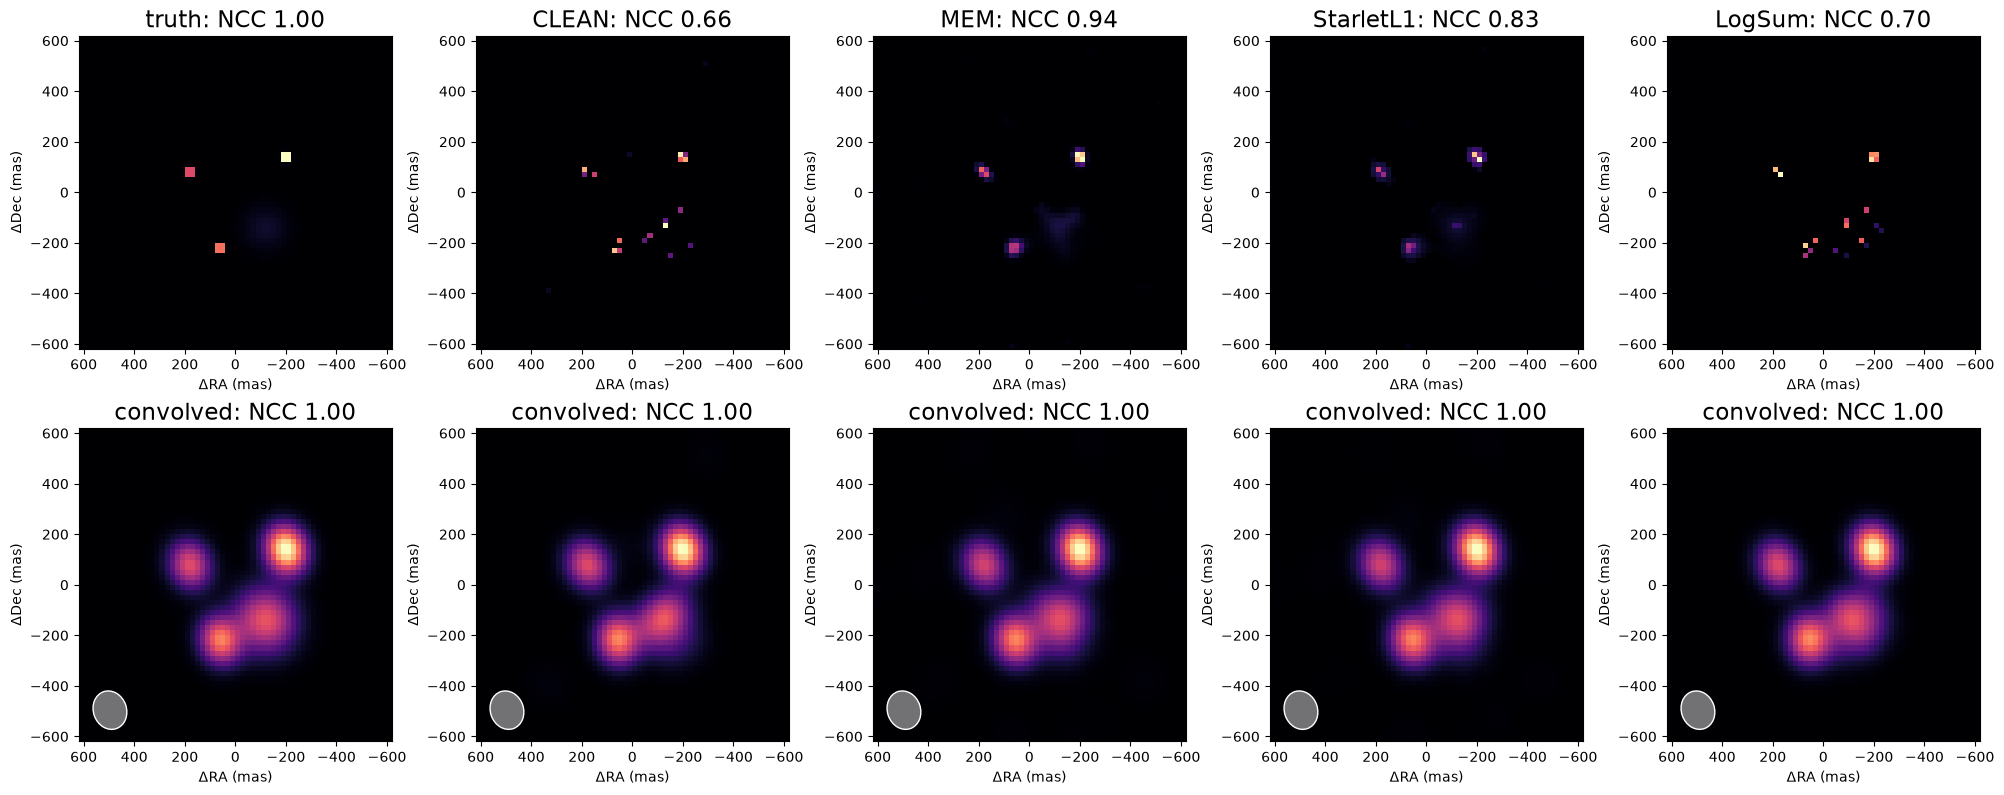

In [4]:
def ncc(a, b):
    a, b = a - a.mean(), b - b.mean()
    return float(jnp.sum(a * b) / jnp.sqrt(jnp.sum(a * a) * jnp.sum(b * b)))


def top(image, fraction=0.02):
    flat = jnp.sort(image.ravel())[::-1]
    return float(flat[: max(1, int(fraction * flat.size))].sum() / flat.sum())


images = {"truth": truth.env, "CLEAN": result.model.clean} | {
    name: r.model.env for name, (w, r) in chosen.items()
}
reference = truth.env.render(npix, fov)
smooth_reference = convolve_beam(reference, scale, resolution)
fig, axes = plt.subplots(2, len(images), figsize=(4 * len(images), 8))
for column, (name, image) in enumerate(images.items()):
    rendered = image.render(npix, fov)
    smooth = convolve_beam(rendered, scale, resolution)
    print(
        f"{name:10s} NCC {ncc(rendered, reference):.2f} native, "
        f"{ncc(smooth, smooth_reference):.2f} convolved; "
        f"top 2% {top(rendered):.2f}"
    )
    plot_model(
        image, fov, npix, ax=axes[0, column],
        title=f"{name}: NCC {ncc(rendered, reference):.2f}",
    )
    plot_model(
        image, fov, npix, ax=axes[1, column], beam=resolution, convolve=True,
        title=f"convolved: NCC {ncc(smooth, smooth_reference):.2f}",
    )
plt.tight_layout()
plt.show()

## Summary

All four reconstructions fit the data (χ² per point 0.93–0.98) and, convolved with the beam, match the truth equally well (NCC 1.00). The data constrain the image only down to the beam; the methods differ in what they put below it:
- **CLEAN** (58 iterations, 21 components, 0.0346 of the 0.035 flux) makes every feature out of points. Its first major cycle, at iteration 50, took χ² per point from about 3.6 to just above one, and eight more iterations reached the target. It scatters the extended blob into a cluster of components (NCC 0.66 at native resolution).
- **Maximum entropy** gives the closest image at native resolution (NCC 0.94), with compact knots and the blob as a faint, diffuse patch.
- **StarletL1** keeps the knots compact and the blob faint (NCC 0.83). Neither it nor MEM converged within 50 000 L-BFGS steps at every weight, although both reached χ²/N ≈ 1.
- **LogSum**, swept with `l_curve(..., warm_start=False)` so that every weight starts from the CLEAN image, is as compact as CLEAN: all of its flux is in the brightest 2% of pixels. Like CLEAN, it breaks the blob into points (NCC 0.70).

So the sparse methods give compact images when compact images are wanted, but no reconstruction can tell whether structure smaller than the beam is real. Compare reconstructions after convolving them with the beam. Swept with warm starts instead, `LogSum` collapsed to a single bright pixel at every weight (χ²/N = 58), because pixels it switches off cannot recover.